# Backtest 001 — Bollinger Squeeze + KMeans Regime Filter

Replaces the HMM regime detector from `backtest_001_hmm_regime.ipynb` with **KMeans clustering**.

## Key difference vs HMM walk-forward

| | HMM walk-forward | KMeans walk-forward |
|---|---|---|
| Regime for day t | Last state from Viterbi on training set | Nearest centroid using **day t's own features** |
| Temporal memory | Yes (transition matrix) | No |
| Regime lag | ~1 month (entire next period = same state) | ~0 (updated every day, centroids frozen monthly) |
| Lookahead risk | None (centroids from past data only) | None (centroids from past data only) |

**KMeans walk-forward algorithm (no lookahead):**
```
Every month-end T:
  1. Train KMeans on features[start : T]   (expanding window)
  2. Freeze centroids + scaler

For each trading day t in (T, next_month_end]:
  3. regime[t] = argmin_k distance(features[t], centroid_k)
     ← uses today's features, but centroids are frozen from past
```

**Features:** `log_ret`, Yang-Zhang volatility, `ma_ratio_50`, `ma_ratio_200`, `rsi_14`

In [23]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns

import vectorbt as vbt
import numba as nb

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl import atr_trailing_nb

plt.style.use('dark_background')
print('imports ok')

imports ok


## 1. Load Data

In [24]:
HDF5_PATH   = pathlib.Path('stocks_data_latest.h5')
S3_ENDPOINT = 'http://192.168.1.3:9000'
S3_TABLE    = 's3://delta-table-storage/stocks'
YEARS_BACK  = 10
BENCHMARK   = 'VNINDEX'

def load_from_delta():
    import deltalake as dl
    opts = {
        'AWS_ACCESS_KEY_ID':          os.environ.get('MINIO_ACCESS_KEY', 'minioadmin'),
        'AWS_SECRET_ACCESS_KEY':      os.environ.get('MINIO_SECRET_KEY', 'minioadmin'),
        'AWS_ENDPOINT_URL':           S3_ENDPOINT,
        'AWS_ALLOW_HTTP':             'true',
        'AWS_S3_ALLOW_UNSAFE_RENAME': 'true',
    }
    df = dl.DeltaTable(S3_TABLE, storage_options=opts).to_pandas()
    df['date'] = pd.to_datetime(df['date'])
    return df

def load_from_hdf5():
    with pd.HDFStore(HDF5_PATH, 'r') as s:
        df = s['stocks']
    if not isinstance(df.index, pd.MultiIndex):
        df = df.reset_index()
        df['date'] = pd.to_datetime(df['date'])
    return df

try:
    print('Loading from DeltaLake …')
    raw = load_from_hdf5()
    print(f'  OK — {len(raw):,} rows')
except Exception as e:
    print(f'  Failed ({e}), falling back to HDF5 …')
    raw = load_from_delta()
    print(f'  HDF5 OK — {len(raw):,} rows')

cutoff = pd.Timestamp.today() - pd.DateOffset(years=YEARS_BACK)

def _wide_field(panel, field_name):
    """(field, symbol) MultiIndex columns → DataFrame indexed by date, columns = symbols."""
    m = panel.columns.get_level_values(0) == field_name
    out = panel.loc[:, m].copy()
    out.columns = out.columns.droplevel(0)
    return out.sort_index()

# ── wide HDF5 (DatetimeIndex × MultiIndex cols) vs long Delta (date, symbol rows) ──
if isinstance(raw.columns, pd.MultiIndex) and raw.columns.nlevels >= 2:
    if not isinstance(raw.index, pd.DatetimeIndex):
        if 'date' in raw.columns:
            raw = raw.set_index(pd.to_datetime(raw['date'])).drop(columns=['date'], errors='ignore')
        else:
            raise ValueError('Wide panel needs DatetimeIndex or a date column')
    raw = raw.sort_index().loc[raw.index >= cutoff]
    open_  = _wide_field(raw, 'open')
    high   = _wide_field(raw, 'high')
    low    = _wide_field(raw, 'low')
    close  = _wide_field(raw, 'close')
    volume = _wide_field(raw, 'volume')
else:
    raw = raw[raw['date'] >= cutoff].copy()
    n_dup = raw.duplicated(subset=['date', 'symbol']).sum()
    if n_dup:
        print(f'  Dropping {n_dup:,} duplicate (date, symbol) rows (keep=last)')
    raw = raw.drop_duplicates(subset=['date', 'symbol'], keep='last')
    pivot = raw.set_index(['date', 'symbol'])
    open_    = pivot['open'].unstack('symbol').sort_index()
    high     = pivot['high'].unstack('symbol').sort_index()
    low      = pivot['low'].unstack('symbol').sort_index()
    close    = pivot['close'].unstack('symbol').sort_index()
    volume   = pivot['volume'].unstack('symbol').sort_index()

# drop symbols with >20% missing
valid_syms = close.columns[close.isna().mean() < 0.2]
close  = close[valid_syms].ffill()
high   = high[valid_syms].ffill()
low    = low[valid_syms].ffill()
open_  = open_[valid_syms].ffill()
volume = volume[valid_syms].ffill().fillna(0)

print(f'Symbols: {len(valid_syms)}  |  {close.index[0].date()} → {close.index[-1].date()}')

# ── benchmark series for HMM ─────────────────────────────────────────────────
if BENCHMARK in close.columns:
    bm_close  = close[BENCHMARK]
    bm_volume = volume[BENCHMARK]
    bm_open   = open_[BENCHMARK]
    bm_high   = high[BENCHMARK]
    bm_low    = low[BENCHMARK]
else:
    # fall back: equal-weight index
    bm_close  = close.mean(axis=1)
    bm_volume = volume.mean(axis=1)
    print(f'  BENCHMARK {BENCHMARK!r} not found — using equal-weight index')

print(f'Benchmark: {BENCHMARK}  rows={len(bm_close)}')

Loading from DeltaLake …
  OK — 2,500 rows
Symbols: 198  |  2016-04-04 → 2026-04-03
Benchmark: VNINDEX  rows=2500


## 2. KMeans Feature Engineering

Richer feature set vs the HMM version:

| Feature | Why |
|---------|-----|
| `log_ret` | Immediate price change |
| `yz_vol` | Yang-Zhang volatility — uses OHLC, unbiased for overnight gaps |
| `ma_ratio_50` | close/MA50 − 1 — medium-term trend position |
| `ma_ratio_200` | close/MA200 − 1 — long-term trend position |
| `rsi_14` | Momentum oscillator |


In [25]:
def yang_zhang_vol(open_, high, low, close, window=20):
    """Yang-Zhang volatility (annualised). Unbiased estimate using OHLC."""
    rs        = (np.log(high/close) * np.log(high/open_) +
                 np.log(low/close)  * np.log(low/open_))
    log_co    = np.log(open_ / close.shift(1))   # overnight
    log_oc    = np.log(close / open_)             # open-to-close
    n         = window
    k         = 0.34 / (1.34 + (n + 1) / (n - 1))
    yz_var    = log_co.rolling(n).var() + k * log_oc.rolling(n).var() + (1-k) * rs.rolling(n).mean()
    return np.sqrt(yz_var.clip(lower=0) * 252)

def calc_rsi(close, period=14):
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    return 100 - (100 / (1 + gain / loss))


KM_FEATURES = ['log_ret', 'yz_vol', 'ma_ratio_50', 'ma_ratio_200', 'rsi_14']

bm_feat = pd.DataFrame(index=bm_close.index)
bm_feat['log_ret']      = np.log(bm_close / bm_close.shift(1))
bm_feat['yz_vol']       = yang_zhang_vol(bm_open, bm_high, bm_low, bm_close, window=20)
bm_feat['ma_ratio_50']  = bm_close / bm_close.rolling(50).mean()  - 1
bm_feat['ma_ratio_200'] = bm_close / bm_close.rolling(200).mean() - 1
bm_feat['rsi_14']       = calc_rsi(bm_close, period=14)
bm_feat = bm_feat.dropna()

print(f'Feature matrix: {bm_feat.shape}  |  {bm_feat.index[0].date()} → {bm_feat.index[-1].date()}')
bm_feat.describe().round(4)

Feature matrix: (2301, 5)  |  2017-01-13 → 2026-04-03


,log_ret,yz_vol,ma_ratio_50,ma_ratio_200,rsi_14
count,2301.0000,2301.0000,2301.0000,2301.0000,2301.0000
mean,0.0004,0.1588,0.0108,0.0451,56.2478
std,0.0121,0.0770,0.0531,0.1143,19.1608
min,-0.0691,0.0514,-0.2601,-0.3115,3.1852
25%,-0.0042,0.1003,-0.0146,-0.0252,41.6123
50%,0.0014,0.1432,0.0156,0.0421,56.4635
75%,0.0064,0.1937,0.0427,0.1051,70.7659
max,0.0655,0.5127,0.1500,0.3419,99.6222


## 3. Walk-Forward KMeans (Zero Lookahead)

**Critical difference vs HMM walk-forward:**  
HMM carries one regime label for the entire next period.  
KMeans re-assigns each day to its nearest centroid — using **today's features** with **centroids frozen from past training**.  
This is still fully causal (centroids only use past data) but much more responsive.

In [26]:
def build_wf_regime_kmeans(
    feat_df,
    feature_cols,
    n_clusters    = 3,
    burn_in       = 252,
    retrain_every = 21,
    random_seed   = 42,
    n_init        = 20,
):
    """
    Walk-forward KMeans regime detection — zero lookahead.

    For each retraining date T:
      1. Fit KMeans + StandardScaler on features[0:T]   (expanding window)
      2. For every day t in (T, next_retrain]:
           regime[t] = nearest centroid using features[t] scaled by the
                       FROZEN scaler from step 1.

    Centroids come from past data → causal.
    Each day gets its own cluster assignment based on its own features → responsive.

    Returns pd.Series of str  ('Bull'|'Neutral'|'Bear'|'Unknown')
    """
    arr    = feat_df[feature_cols].values.astype(float)
    idx    = feat_df.index
    n      = len(arr)
    labels = np.full(n, 'Unknown', dtype=object)

    retrain_pts = list(range(burn_in - 1, n - 1, retrain_every))
    name_map_3  = ['Bear', 'Neutral', 'Bull']
    name_map_2  = ['Bear', 'Bull']

    for ri, tend in enumerate(retrain_pts):
        # ── 1. fit on expanding window ────────────────────────────────────────
        scaler   = StandardScaler()
        X_train  = scaler.fit_transform(arr[:tend + 1])
        km       = KMeans(n_clusters=n_clusters, n_init=n_init,
                          random_state=random_seed, max_iter=300)
        km.fit(X_train)

        # ── 2. label clusters by mean log-return (index 0 = first feature col) ─
        train_clusters = km.labels_
        mean_r   = {c: arr[:tend+1, 0][train_clusters == c].mean()
                    for c in range(n_clusters)}
        ranked   = sorted(mean_r, key=mean_r.get)
        names    = name_map_2 if n_clusters == 2 else name_map_3
        lmap     = {ranked[i]: names[i] for i in range(n_clusters)}

        # ── 3. assign regime for each future day using FROZEN centroids ────────
        next_tend  = retrain_pts[ri + 1] if ri + 1 < len(retrain_pts) else n
        X_future   = arr[tend + 1 : next_tend]
        if len(X_future) == 0:
            continue
        X_future_s = scaler.transform(X_future)        # frozen scaler
        clusters   = km.predict(X_future_s)            # nearest centroid
        for offset, c in enumerate(clusters):
            labels[tend + 1 + offset] = lmap[c]

    return pd.Series(labels, index=idx, name='km_regime')

In [27]:
K_REGIMES     = 3
BURN_IN       = 252
RETRAIN_EVERY = 21
RANDOM_SEED   = 42

print('Running walk-forward KMeans …')
regime_km = build_wf_regime_kmeans(
    bm_feat,
    KM_FEATURES,
    n_clusters    = K_REGIMES,
    burn_in       = BURN_IN,
    retrain_every = RETRAIN_EVERY,
    random_seed   = RANDOM_SEED,
)
print('Done.')
print(regime_km.value_counts())

Running walk-forward KMeans …
Done.
km_regime
Neutral    939
Bear       511
Bull       502
Unknown    349
Name: count, dtype: int64


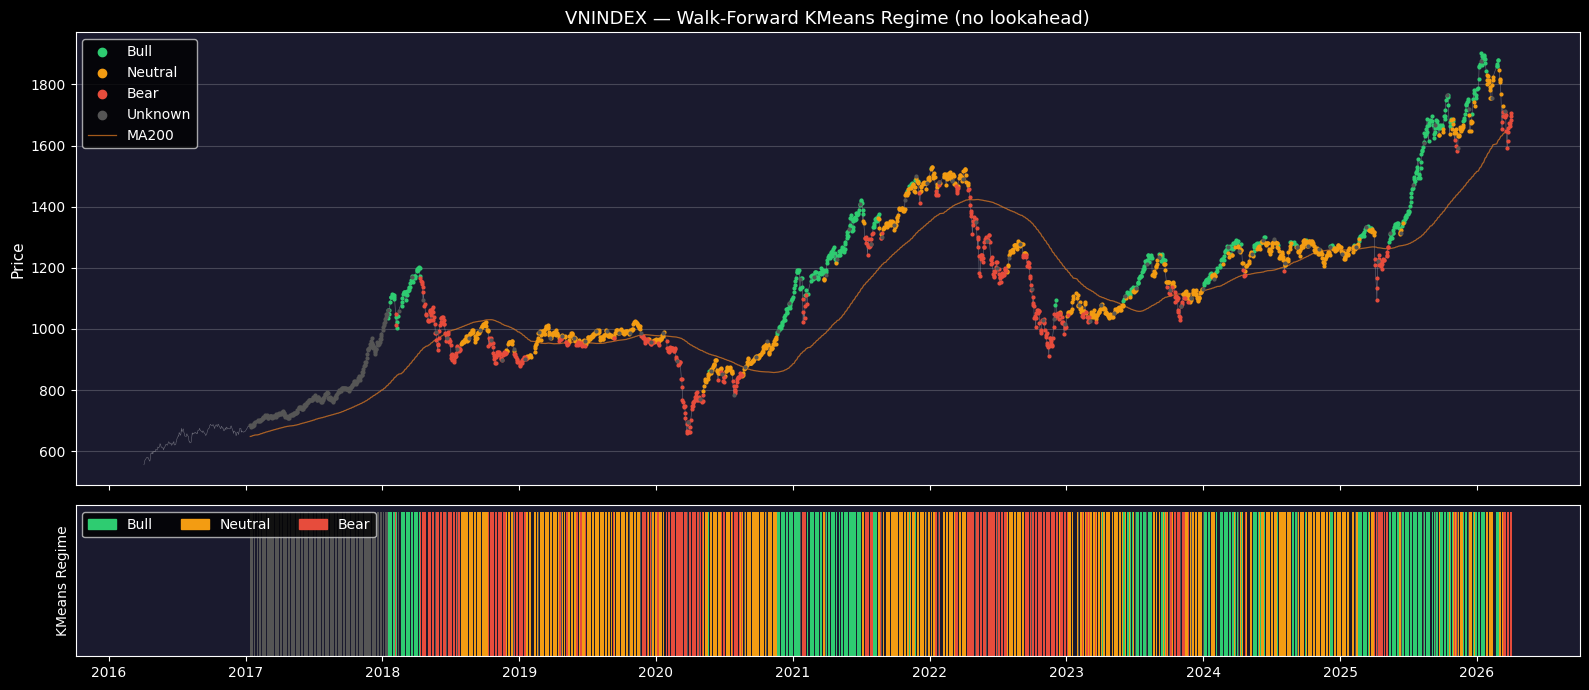

In [28]:
COLOR = {'Bull': '#2ecc71', 'Neutral': '#f39c12', 'Bear': '#e74c3c', 'Unknown': '#555555'}

regime_aligned = regime_km.reindex(close.index)
common_bm      = bm_close.index.intersection(regime_km.index)

fig, axes = plt.subplots(2, 1, figsize=(16, 7),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax = axes[0]; ax.set_facecolor('#1a1a2e')
for lbl, col in COLOR.items():
    mask = regime_km.reindex(common_bm) == lbl
    ax.scatter(common_bm[mask], bm_close.reindex(common_bm)[mask],
               s=4, c=col, label=lbl, zorder=3)
ax.plot(bm_close.index, bm_close.values, color='white', lw=0.4, alpha=0.35)
ma200 = bm_close.rolling(200).mean()
ax.plot(ma200.index, ma200.values, color='#e67e22', lw=0.9, alpha=0.7, label='MA200')
ax.set_ylabel('Price', fontsize=11)
ax.set_title(f'{BENCHMARK} — Walk-Forward KMeans Regime (no lookahead)', fontsize=13)
ax.legend(loc='upper left', markerscale=3); ax.yaxis.grid(True, alpha=0.2)

ax2 = axes[1]; ax2.set_facecolor('#1a1a2e')
colors_bar = [COLOR.get(r, '#555') for r in regime_km.reindex(common_bm)]
ax2.bar(common_bm, np.ones(len(common_bm)), color=colors_bar, width=1.5)
ax2.set_yticks([]); ax2.set_ylabel('KMeans Regime')
patches = [mpatches.Patch(color=c, label=l) for l, c in COLOR.items() if l != 'Unknown']
ax2.legend(handles=patches, loc='upper left', ncol=3)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout(); plt.show()

## 4. Bollinger Squeeze + DeMarker Strategy (Baseline)

In [29]:
@nb.njit(cache=True)
def bollinger_squeeze_demarker_nb(
    high_arr, low_arr, close_arr,
    demarker_period: int   = 11,
    keltner_period:  int   = 16,
    bb_period:       int   = 15,
    bb_deviation:    float = 2.3,
    keltner_factor:  float = 2.2,
):
    n          = len(close_arr)
    squeeze_on = np.zeros(n, dtype=nb.boolean)
    direction  = np.zeros(n, dtype=nb.int64)
    start      = max(demarker_period, keltner_period, bb_period)

    for i in range(start, n):
        # DeMarker
        dh, dl = 0.0, 0.0
        for j in range(i - demarker_period + 1, i + 1):
            dh += max(high_arr[j]  - high_arr[j-1],  0.0)
            dl += max(low_arr[j-1] - low_arr[j],      0.0)
        dem = dh / (dh + dl) if (dh + dl) != 0.0 else 0.5

        # Bollinger Bands
        bb_sl = close_arr[i - bb_period + 1 : i + 1]
        bb_w  = bb_deviation * bb_sl.std() * 2

        # Keltner Channel (SMA-based ATR)
        atr_s = 0.0
        for j in range(i - keltner_period + 1, i + 1):
            atr_s += max(high_arr[j], close_arr[j-1]) - min(low_arr[j], close_arr[j-1])
        kc_w  = 2.0 * keltner_factor * atr_s / keltner_period

        squeeze_on[i] = bb_w < kc_w
        direction[i]  = 1 if dem > 0.5 else -1

    return squeeze_on, direction

print('Numba indicator compiled')

Numba indicator compiled


In [30]:
DEMARKER_PERIOD = 11
KELTNER_PERIOD  = 16
BB_PERIOD       = 15
BB_DEVIATION    = 2.3
KELTNER_FACTOR  = 2.2
ATR_PERIOD      = 10
ATR_MULTIPLIER  = 1.8
SL_STOP         = 0.10
INIT_CASH       = 100

squeeze_on_dict = {}
direction_dict  = {}
for sym in valid_syms:
    sq, dr = bollinger_squeeze_demarker_nb(
        high[sym].values, low[sym].values, close[sym].values,
        DEMARKER_PERIOD, KELTNER_PERIOD, BB_PERIOD, BB_DEVIATION, KELTNER_FACTOR,
    )
    squeeze_on_dict[sym] = sq
    direction_dict[sym]  = dr

squeeze_on_df = pd.DataFrame(squeeze_on_dict, index=close.index)
direction_df  = pd.DataFrame(direction_dict,  index=close.index)

# ATR trailing stop (shift by 1 — no lookahead)
atr_raw   = vbt.IndicatorFactory.from_talib('ATR').run(high, low, close, timeperiod=ATR_PERIOD)
atr_scope = atr_raw.real.shift(1)

ATRTrailing = vbt.IndicatorFactory(
    input_names=['close', 'atr'], param_names=['atr_multiplier'], output_names=['atr_trailing'],
).from_apply_func(atr_trailing_nb)
atr_sl = ATRTrailing.run(close, atr_scope, atr_multiplier=ATR_MULTIPLIER)

# Signals
entries_base = (squeeze_on_df.shift(1).fillna(False) & ~squeeze_on_df) & (direction_df == 1)
exits        = close.vbt.crossed_below(atr_sl.atr_trailing)

print(f'Baseline entry signals: {entries_base.sum().sum():,}')

Baseline entry signals: 9,157


## 5. Apply KMeans Regime Filter

In [31]:
def broadcast_mask(series_mask, columns):
    return pd.DataFrame(
        np.tile(series_mask.values.reshape(-1, 1), (1, len(columns))),
        index=series_mask.index, columns=columns,
    )

# ── filter variants ───────────────────────────────────────────────────────────
# A: block Bear only
mask_bn   = broadcast_mask(regime_aligned.isin(['Bull', 'Neutral']), valid_syms)
# B: block Bear + Neutral
mask_bull = broadcast_mask(regime_aligned == 'Bull', valid_syms)

entries_bn   = entries_base & mask_bn
entries_bull = entries_base & mask_bull

# ── position sizing variant ───────────────────────────────────────────────────
SIZING_MAP = {'Bull': 1.0, 'Neutral': 0.5, 'Bear': 0.25, 'Unknown': 1.0}
size_frac  = regime_aligned.map(SIZING_MAP).fillna(1.0)
size_frac_df = broadcast_mask(size_frac, valid_syms)
share_size_df = (size_frac_df * INIT_CASH / close).fillna(0).replace([np.inf, -np.inf], 0)

print(f'Entry signals — Baseline     : {entries_base.sum().sum():,}')
print(f'Entry signals — Bull+Neutral : {entries_bn.sum().sum():,}')
print(f'Entry signals — Bull only    : {entries_bull.sum().sum():,}')

Entry signals — Baseline     : 9,157
Entry signals — Bull+Neutral : 6,445
Entry signals — Bull only    : 2,620


## 6. Backtests

In [32]:
COMMON = dict(freq='1d', group_by=False, cash_sharing=False,
              sl_stop=SL_STOP, init_cash=INIT_CASH)

print('Running Baseline …')
pf_base = vbt.Portfolio.from_signals(close=close, entries=entries_base,  exits=exits, **COMMON)

print('Running KMeans Bull+Neutral filter …')
pf_bn   = vbt.Portfolio.from_signals(close=close, entries=entries_bn,    exits=exits, **COMMON)

print('Running KMeans Bull-only filter …')
pf_bull = vbt.Portfolio.from_signals(close=close, entries=entries_bull,  exits=exits, **COMMON)

print('Running KMeans position sizing …')
pf_sz   = vbt.Portfolio.from_signals(close=close, entries=entries_base,  exits=exits,
                                      size=share_size_df, **COMMON)
print('Done.')

Running Baseline …
Running KMeans Bull+Neutral filter …
Running KMeans Bull-only filter …
Running KMeans position sizing …
Done.


## 7. Results

In [33]:
def full_stats(pf, name):
    s = pf.sharpe_ratio()
    return pd.Series({
        'Name':             name,
        'Sharpe mean':      s.mean().round(3),
        'Sharpe median':    s.median().round(3),
        'Sharpe > 1':       f'{(s > 1).sum()}/{len(s)}',
        'Sortino mean':     pf.sortino_ratio().mean().round(3),
        'Calmar mean':      pf.calmar_ratio().mean().round(3),
        'Total Ret mean':   f'{pf.total_return().mean():.1%}',
        'Max DD mean':      f'{pf.max_drawdown().mean():.1%}',
        'Max DD worst':     f'{pf.max_drawdown().min():.1%}',
        'N Trades':         int(pf.trades.count().sum()),
        'Avg Trade Ret':    f'{pd.Series(pf.trades.returns.mean()).mean():.2%}',
        'Win Rate':         f'{pf.trades.win_rate().mean():.1%}',
        'Profit Factor':    pf.trades.profit_factor().mean().round(3),
    })

table = pd.DataFrame([
    full_stats(pf_base, 'Baseline'),
    full_stats(pf_bn,   'KMeans Bull+Neutral'),
    full_stats(pf_bull, 'KMeans Bull only'),
    full_stats(pf_sz,   'KMeans Pos Sizing'),
]).set_index('Name')

display(table.T)

Name,Baseline,KMeans Bull+Neutral,KMeans Bull only,KMeans Pos Sizing
Sharpe mean,0.482,0.345,0.211,0.5
Sharpe median,0.498,0.333,0.184,0.49
Sharpe > 1,22/198,16/198,8/198,24/198
Sortino mean,0.776,0.567,0.391,0.847
Calmar mean,0.317,0.222,0.159,0.351
Total Ret mean,144.1%,78.0%,32.6%,62.7%
Max DD mean,-36.6%,-33.1%,-25.7%,-23.9%
Max DD worst,-72.9%,-59.6%,-52.4%,-71.4%
N Trades,7039,5080,2145,7039
Avg Trade Ret,2.64%,2.40%,2.70%,2.64%


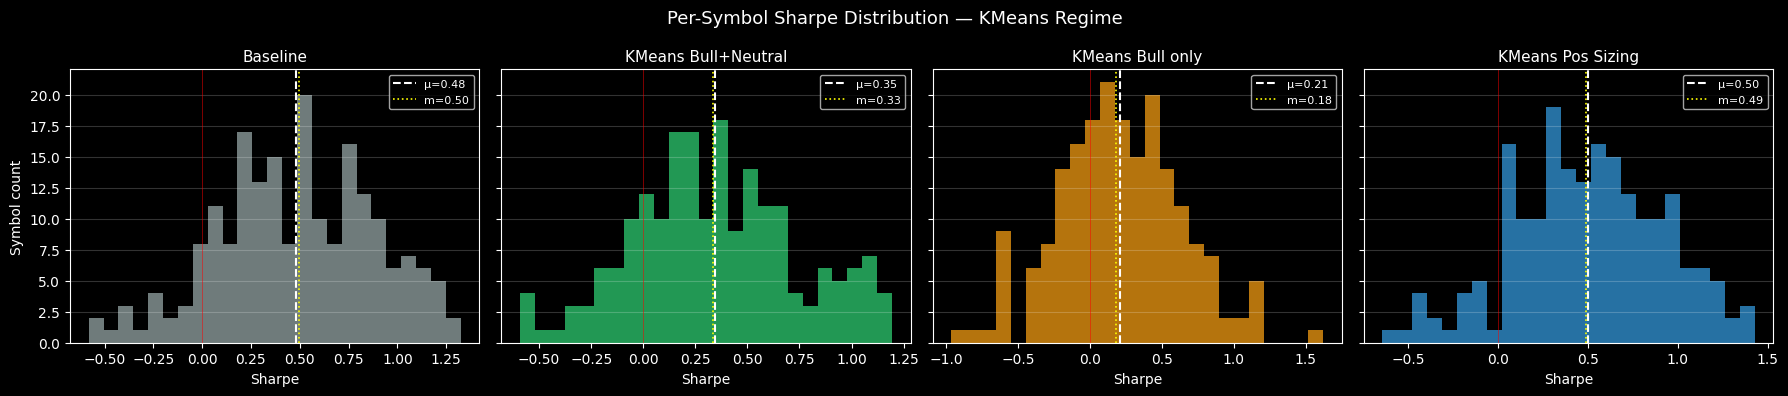

In [34]:
# ── Sharpe distribution ───────────────────────────────────────────────────────
pfs_all = [
    (pf_base, 'Baseline',            '#95a5a6'),
    (pf_bn,   'KMeans Bull+Neutral', '#2ecc71'),
    (pf_bull, 'KMeans Bull only',    '#f39c12'),
    (pf_sz,   'KMeans Pos Sizing',   '#3498db'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, (pf, name, col) in zip(axes, pfs_all):
    sv = pf.sharpe_ratio().dropna()
    ax.hist(sv, bins=25, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(sv.mean(),   color='white',  lw=1.5, ls='--', label=f'μ={sv.mean():.2f}')
    ax.axvline(sv.median(), color='yellow', lw=1.2, ls=':',  label=f'm={sv.median():.2f}')
    ax.axvline(0, color='red', lw=0.7, alpha=0.5)
    ax.set_title(name, fontsize=11); ax.set_xlabel('Sharpe')
    ax.legend(fontsize=8); ax.yaxis.grid(True, alpha=0.2)
axes[0].set_ylabel('Symbol count')
fig.suptitle('Per-Symbol Sharpe Distribution — KMeans Regime', fontsize=13)
fig.tight_layout(); plt.show()

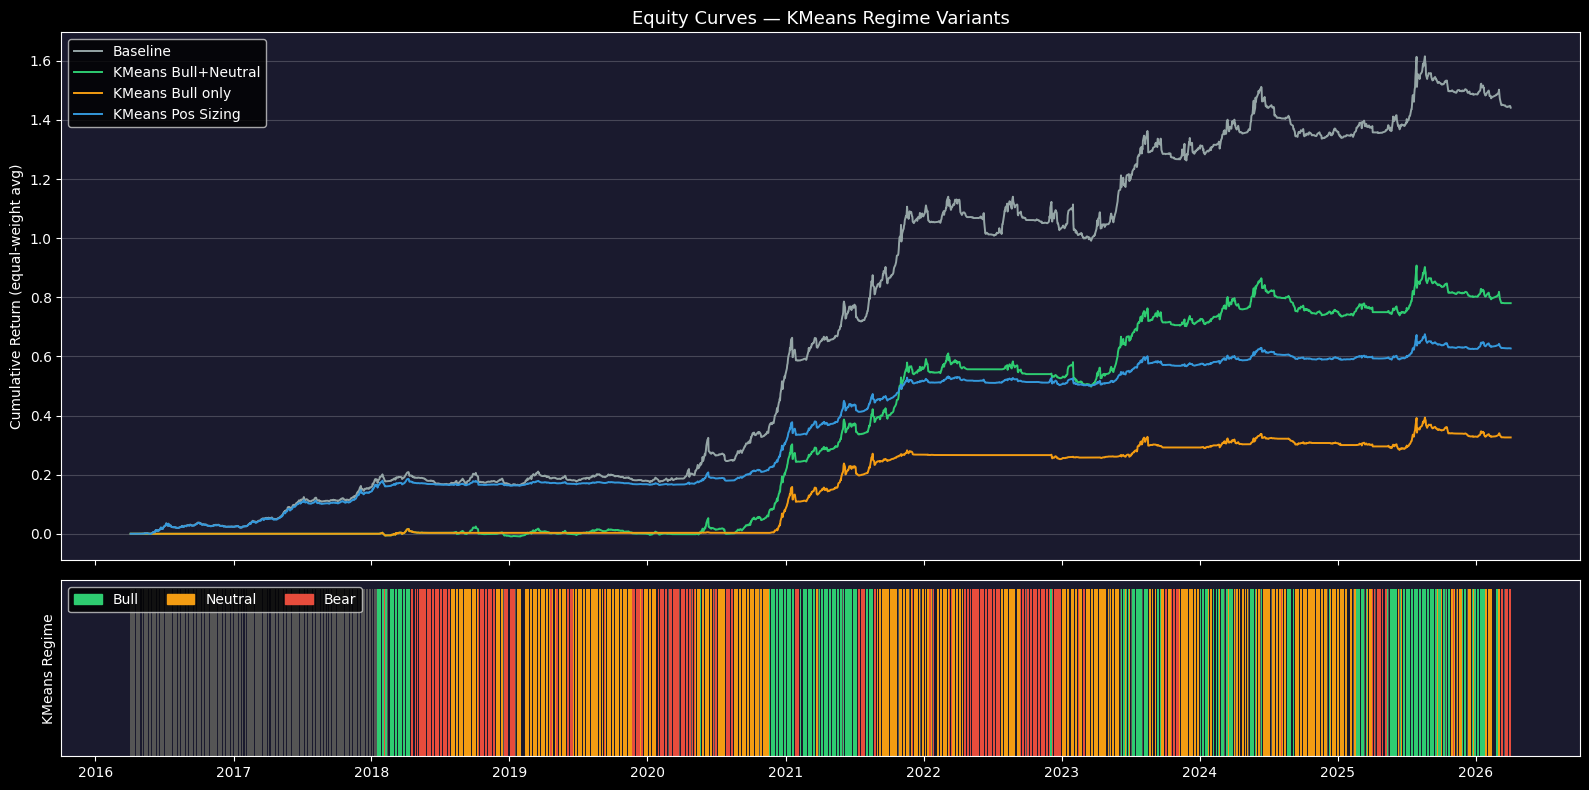

In [35]:
# ── equity curves + regime background ────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax = axes[0]; ax.set_facecolor('#1a1a2e')
for pf, name, col in pfs_all:
    cum = pf.cumulative_returns().mean(axis=1)
    ax.plot(cum.index, cum.values, label=name, lw=1.4, color=col)
ax.set_ylabel('Cumulative Return (equal-weight avg)')
ax.set_title('Equity Curves — KMeans Regime Variants', fontsize=13)
ax.legend(); ax.yaxis.grid(True, alpha=0.2)

ax2 = axes[1]; ax2.set_facecolor('#1a1a2e')
colors_bar = [COLOR.get(r, '#555') for r in regime_aligned.reindex(close.index)]
ax2.bar(close.index, np.ones(len(close)), color=colors_bar, width=1.5)
ax2.set_yticks([]); ax2.set_ylabel('KMeans Regime')
patches = [mpatches.Patch(color=c, label=l) for l, c in COLOR.items() if l != 'Unknown']
ax2.legend(handles=patches, loc='upper left', ncol=3)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout(); plt.show()

KMeans Bull+Neutral: improved 56/198 symbols  mean Δ=-0.136
KMeans Bull only: improved 47/198 symbols  mean Δ=-0.270
KMeans Pos Sizing: improved 106/198 symbols  mean Δ=+0.018


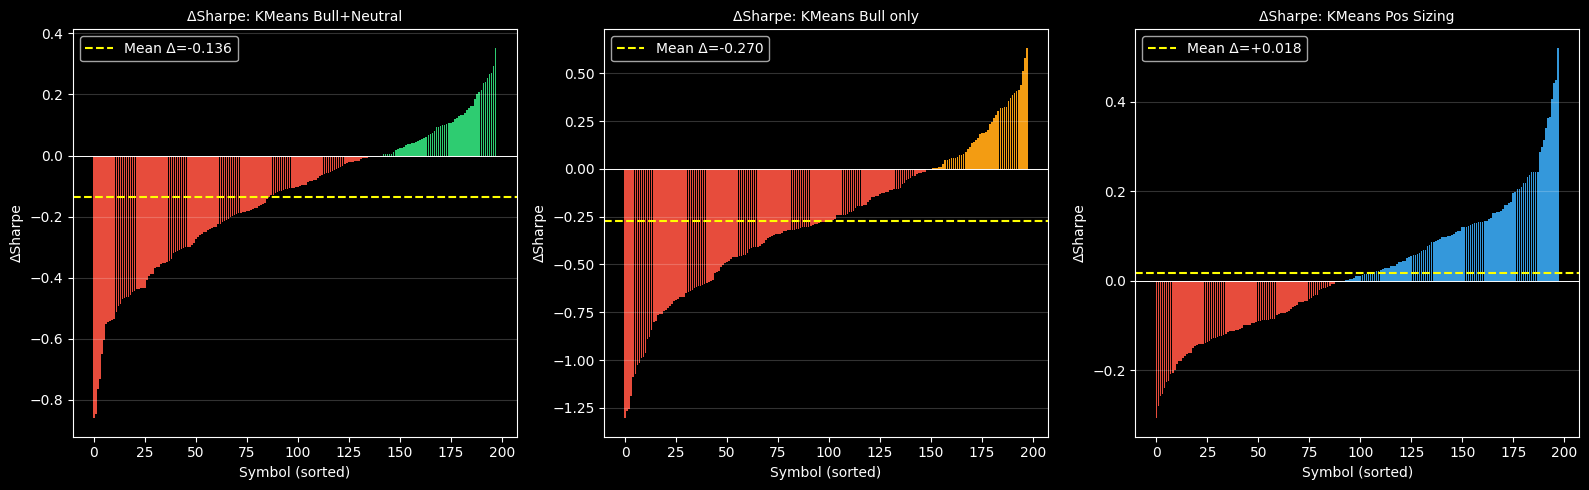

In [36]:
# ── ΔSharpe: KMeans variants vs baseline ─────────────────────────────────────
s_base = pf_base.sharpe_ratio()
deltas = [
    (pf_bn,   'KMeans Bull+Neutral', '#2ecc71'),
    (pf_bull, 'KMeans Bull only',    '#f39c12'),
    (pf_sz,   'KMeans Pos Sizing',   '#3498db'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (pf, name, col) in zip(axes, deltas):
    delta = (pf.sharpe_ratio() - s_base).dropna().sort_values()
    ax.bar(range(len(delta)), delta,
           color=[col if v >= 0 else '#e74c3c' for v in delta])
    ax.axhline(0, color='white', lw=0.7)
    ax.axhline(delta.mean(), color='yellow', lw=1.5, ls='--',
               label=f'Mean Δ={delta.mean():+.3f}')
    ax.set_title(f'ΔSharpe: {name}', fontsize=10)
    ax.set_xlabel('Symbol (sorted)'); ax.set_ylabel('ΔSharpe')
    ax.legend(); ax.yaxis.grid(True, alpha=0.2)

    improved = (delta > 0).sum()
    print(f'{name}: improved {improved}/{len(delta)} symbols  mean Δ={delta.mean():+.3f}')

fig.tight_layout(); plt.show()

## 8. Trade Analysis — Return by Regime at Entry

In [37]:
trades = pf_base.trades.records_readable.copy()
_entry_col = next((c for c in ('Entry Timestamp', 'Entry Index') if c in trades.columns), None)
if _entry_col is None:
    raise KeyError(f"No entry time column; columns={list(trades.columns)}")
trades['entry_regime'] = trades[_entry_col].map(regime_aligned).fillna('Unknown')

trade_stats = (
    trades.groupby('entry_regime')
    .agg(
        n_trades    = ('Return', 'count'),
        win_rate    = ('Return', lambda x: (x > 0).mean()),
        avg_ret     = ('Return', 'mean'),
        median_ret  = ('Return', 'median'),
        sharpe_like = ('Return', lambda x: x.mean() / x.std() if x.std() > 0 else 0),
    ).round(4)
)
print('Trade stats by KMeans regime at entry:')
display(trade_stats)

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
regime_colors = {'Bull': '#2ecc71', 'Neutral': '#f39c12', 'Bear': '#e74c3c', 'Unknown': '#555'}
for ax, col_name, ylabel in [
    (axes[0], 'avg_ret',     'Avg Trade Return'),
    (axes[1], 'win_rate',    'Win Rate'),
    (axes[2], 'sharpe_like', 'Sharpe-like ratio'),
]:
    vals   = trade_stats[col_name]
    colors = [regime_colors.get(r, '#555') for r in vals.index]
    ax.bar(vals.index, vals.values, color=colors, edgecolor='none')
    ax.axhline(0, color='white', lw=0.7, alpha=0.5)
    ax.set_title(ylabel, fontsize=11); ax.yaxis.grid(True, alpha=0.2)

fig.suptitle('Trade Quality by KMeans Regime at Entry (Baseline Trades)', fontsize=13)
fig.tight_layout(); plt.show()

KeyError: 'Entry Index'

## 9. KMeans vs HMM — Side-by-Side Reference

Paste HMM results from `backtest_001_hmm_regime.ipynb` here for direct comparison.

In [ ]:
# ── fill in from the HMM notebook output ─────────────────────────────────────
# These are reference values; update after running backtest_001_hmm_regime.ipynb
HMM_RESULTS = {
    'Baseline':               0.542,
    'HMM Bull+Neutral':       0.366,
    'HMM Bull only':          0.294,
    'Option A 3-state sizing': None,   # fill after running
    'Option B2 2-state sizing': None,  # fill after running
}

KM_RESULTS = {
    'Baseline':                  pf_base.sharpe_ratio().mean(),
    'KMeans Bull+Neutral':       pf_bn.sharpe_ratio().mean(),
    'KMeans Bull only':          pf_bull.sharpe_ratio().mean(),
    'KMeans Pos Sizing':         pf_sz.sharpe_ratio().mean(),
}

# ── bar chart comparison ──────────────────────────────────────────────────────
all_labels = sorted(set(list(HMM_RESULTS.keys()) + list(KM_RESULTS.keys())))

hmm_vals = [HMM_RESULTS.get(l, np.nan) for l in all_labels]
km_vals  = [KM_RESULTS.get(l,  np.nan) for l in all_labels]

x     = np.arange(len(all_labels))
W_BAR = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_facecolor('#1a1a2e')
ax.bar(x - W_BAR/2, hmm_vals, W_BAR, label='HMM',    color='#9b59b6', alpha=0.85, edgecolor='none')
ax.bar(x + W_BAR/2, km_vals,  W_BAR, label='KMeans', color='#3498db', alpha=0.85, edgecolor='none')
ax.axhline(KM_RESULTS['Baseline'], ls='--', color='white', lw=0.9, alpha=0.5, label='Baseline')
ax.set_xticks(x); ax.set_xticklabels(all_labels, rotation=20, ha='right')
ax.set_ylabel('Mean Sharpe Ratio')
ax.set_title('HMM vs KMeans Regime Filter — Sharpe Comparison', fontsize=13)
ax.legend(); ax.yaxis.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()

print('\n=== KMeans Results ===')
for name, val in KM_RESULTS.items():
    baseline = KM_RESULTS['Baseline']
    delta = f'({val - baseline:+.3f})' if name != 'Baseline' else ''
    print(f'  {name:<30s}: {val:.3f}  {delta}')

In [ ]:
# ── final verdict ─────────────────────────────────────────────────────────────
best_name = max(KM_RESULTS, key=KM_RESULTS.get)
best_val  = KM_RESULTS[best_name]
baseline  = KM_RESULTS['Baseline']

print('=' * 55)
print('  KMEANS REGIME — SHARPE SUMMARY')
print('=' * 55)
for name, val in KM_RESULTS.items():
    marker = ' ◄ BEST' if name == best_name else ''
    delta  = f'({val - baseline:+.3f})' if name != 'Baseline' else '         '
    print(f'  {name:<30s}: {val:.3f}  {delta}{marker}')
print('=' * 55)